# Tutorial 8 — Information-Theoretic Metacognition (`metasignal.itmc`)

`itmc` implements the information-theoretic metacognition measures of
[Dayan (2023)](https://doi.org/10.1162/opmi_a_00091), which treat
metacognitive sensitivity as the mutual information between accuracy and
confidence rather than assuming a Gaussian SDT model. `meta_Ir1_acc` and
`RMI` extend the framework via
[Rausch et al. (2025), statConfR](https://doi.org/10.21105/joss.06966).

> **Experimental** — `itmc` is a pre-1.0 component; see the
> [API Reference](../api.md#itmc-information-theoretic-metacognition-experimental)
> for validation details against the R `statConfR` package.

| Measure | Meaning |
| --- | --- |
| `meta_I` | Mutual information between confidence and accuracy (bits) |
| `meta_Ir1` | Efficiency relative to an ideal Gaussian observer with the same d′ |
| `meta_Ir1_acc` | Same, normalised by observed accuracy instead of d′ |
| `meta_Ir2` | Fraction of the maximum possible information, range [0, 1] |
| `RMI` | Range-normalised information; 0 = worst, 1 = best metacognition |

| `backend=` | Best for |
| --- | --- |
| `'simple'` (default) | Fast exploration; `meta_I`, `meta_Ir1`, `meta_Ir2` |
| `'statconfr'` | Exact reproduction of statConfR results; required for `RMI` |

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metasignal import stdpy
from metasignal.itmc import (
    meta_I, meta_Ir1, meta_Ir1_acc, meta_Ir2, RMI,
    estimate_meta_I, fit_group, MEASURE_COLS,
)

COLORS = {"simple": "#4C72B0", "statconfr": "#DD8452"}

## 1. Single-participant quick start

Simulate one participant and compute all five measures with both backends.

In [2]:
rng = np.random.default_rng(0)
df = stdpy.trialSimulation(d=1.5, metad=1.2, nTrials=600, rng=rng)

stim = df["Stimuli"].to_numpy(int)
resp = df["Responses"].to_numpy(int)
conf = df["Confidence"].to_numpy(int)

print(f"Trials: {len(stim)}   Accuracy: {(stim == resp).mean():.2f}")

pd.DataFrame([
    {
        "backend": backend,
        "meta_I": meta_I(stim, resp, conf, backend=backend),
        "meta_Ir1": meta_Ir1(stim, resp, conf, backend=backend),
        "meta_Ir1_acc": meta_Ir1_acc(stim, resp, conf, backend=backend),
        "meta_Ir2": meta_Ir2(stim, resp, conf, backend=backend),
        "RMI": RMI(stim, resp, conf, backend=backend),
    }
    for backend in ["simple", "statconfr"]
]).set_index("backend").round(4)

Trials: 600   Accuracy: 0.77


,meta_I,meta_Ir1,meta_Ir1_acc,meta_Ir2,RMI
backend,,,,,
simple,0.0614,0.7386,0.7386,0.0795,-0.2156
statconfr,0.0645,0.7079,0.7079,0.0836,0.2024


## 2. meta-I is ≈ 0 for uninformative confidence

Shuffling confidence breaks the accuracy-confidence link, so meta-I should
collapse to approximately zero.

In [3]:
rng2 = np.random.default_rng(1)
conf_random = rng2.integers(1, 5, size=len(stim))

mi_real = meta_I(stim, resp, conf, backend="statconfr")
mi_random = meta_I(stim, resp, conf_random, backend="statconfr")

print(f"meta-I (informative confidence): {mi_real:.4f} bits")
print(f"meta-I (random confidence):      {mi_random:.4f} bits  <- should be ~ 0")

meta-I (informative confidence): 0.0645 bits
meta-I (random confidence):      0.0070 bits  <- should be ~ 0


## 3. meta-Ir1 tracks meta-d′ at fixed d′

`meta_Ir1` measures efficiency relative to an ideal Gaussian observer.
Values below 1 indicate sub-ideal metacognition.

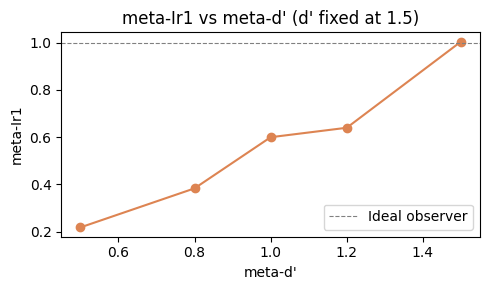

In [4]:
dprime_fixed = 1.5
metad_levels = [0.5, 0.8, 1.0, 1.2, 1.5]

ir1_vals = []
for md in metad_levels:
    d = stdpy.trialSimulation(d=dprime_fixed, metad=md, nTrials=2000,
                               rng=np.random.default_rng(99))
    ir1_vals.append(meta_Ir1(d["Stimuli"].to_numpy(int), d["Responses"].to_numpy(int),
                              d["Confidence"].to_numpy(int), backend="statconfr"))

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(metad_levels, ir1_vals, "o-", color=COLORS["statconfr"])
ax.axhline(1.0, ls="--", color="gray", lw=0.8, label="Ideal observer")
ax.set_xlabel("meta-d'")
ax.set_ylabel("meta-Ir1")
ax.set_title(f"meta-Ir1 vs meta-d' (d' fixed at {dprime_fixed})")
ax.legend()
plt.tight_layout()
plt.show()

## 4. meta-Ir2 and RMI — bounded [0, 1] alternatives

`meta_Ir2` is the fraction of the *maximum possible* information
transmitted. `RMI` rescales between the analytic min/max I(S;R) at the
observed accuracy level (Dayan 2023, Theorem 3) — always use
`backend='statconfr'` for RMI, the `'simple'`-backend bounds are not tight.

In [5]:
print(f"meta-Ir2 (simple):    {meta_Ir2(stim, resp, conf, backend='simple'):.4f}")
print(f"meta-Ir2 (statconfr): {meta_Ir2(stim, resp, conf, backend='statconfr'):.4f}")
print(f"RMI      (statconfr): {RMI(stim, resp, conf, backend='statconfr'):.4f}")

meta-Ir2 (simple):    0.0795
meta-Ir2 (statconfr): 0.0836
RMI      (statconfr): 0.2024


## 5. Bias correction for small samples

meta-I has a positive sampling bias at low N (mutual information is always
≥ 0, even under the null). `bias_correction=True` subtracts an estimated
bias — permutation of accuracy labels for `'simple'`, multinomial
resampling of the contingency table for `'statconfr'` (matching
statConfR's `bias_reduction=TRUE`).

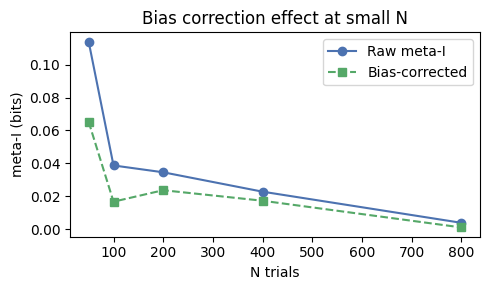

In [6]:
n_trials_list = [50, 100, 200, 400, 800]
raw_vals, bc_vals = [], []
for n in n_trials_list:
    d = stdpy.trialSimulation(d=1.0, metad=0.3, nTrials=n, rng=np.random.default_rng(7))
    s = d["Stimuli"].to_numpy(int)
    r = d["Responses"].to_numpy(int)
    c = d["Confidence"].to_numpy(int)
    raw_vals.append(meta_I(s, r, c, backend="simple", bias_correction=False))
    bc_vals.append(meta_I(s, r, c, backend="simple", bias_correction=True, seed=0))

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(n_trials_list, raw_vals, "o-", label="Raw meta-I", color=COLORS["simple"])
ax.plot(n_trials_list, bc_vals, "s--", label="Bias-corrected", color="#55A868")
ax.set_xlabel("N trials")
ax.set_ylabel("meta-I (bits)")
ax.set_title("Bias correction effect at small N")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Group-level analysis with `estimate_meta_I`

`estimate_meta_I(df)` mirrors statConfR's `estimateMetaI()`: one row per
participant, all five measures. Expected columns: `stimulus`, `response`,
`rating`, `participant` (overridable via `*_col=`).

In [7]:
records = []
for pid in range(10):
    d = stdpy.trialSimulation(d=1.2 + 0.1 * pid, metad=0.8 + 0.05 * pid, nTrials=400,
                               rng=np.random.default_rng(pid))
    d = d.rename(columns={"Stimuli": "stimulus", "Responses": "response", "Confidence": "rating"})
    d["participant"] = f"p{pid:02d}"
    records.append(d[["stimulus", "response", "rating", "participant"]])

df_group = pd.concat(records, ignore_index=True)
result = estimate_meta_I(df_group, backend="statconfr")
result.round(4)

,participant,meta_I,meta_Ir1,meta_Ir1_acc,meta_Ir2,RMI
0,p00,0.0235,0.3446,0.3446,0.0277,0.0788
1,p01,0.0460,0.6093,0.6093,0.0556,0.1499
2,p02,0.0572,0.6729,0.6729,0.0719,0.1815
3,p03,0.0448,0.4880,0.4880,0.0583,0.1405
4,p04,0.0410,0.4161,0.4161,0.0553,0.1275
5,p05,0.0564,0.5489,0.5489,0.0781,0.1751
6,p06,0.0627,0.5774,0.5774,0.0907,0.1952
7,p07,0.0798,0.7021,0.7021,0.1213,0.2512
8,p08,0.0679,0.5817,0.5817,0.1070,0.2159
9,p09,0.0359,0.2981,0.2981,0.0601,0.1168


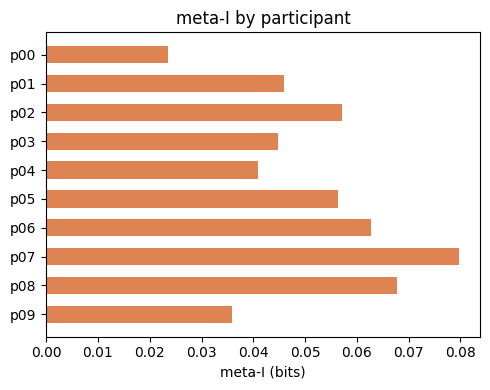

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.barh(result["participant"], result["meta_I"], color=COLORS["statconfr"], height=0.6)
ax.set_xlabel("meta-I (bits)")
ax.set_title("meta-I by participant")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Factorial designs with `fit_group`

`fit_group` accepts `subject`, `within`, and `between` columns — including
lists of multiple factors — and returns one row per cell.

In [9]:
records2 = []
for pid in range(8):
    for cond, label in [(0, "easy"), (1, "hard")]:
        d_level = 2.0 if cond == 0 else 1.0
        p = stdpy.trialSimulation(d=d_level, metad=d_level * 0.8, nTrials=300,
                                   rng=np.random.default_rng(pid * 10 + cond))
        p = p.rename(columns={"Stimuli": "stimulus", "Responses": "response", "Confidence": "rating"})
        p["subject"] = f"p{pid:02d}"
        p["condition"] = label
        p["group"] = "control" if pid < 4 else "patient"
        records2.append(p[["stimulus", "response", "rating", "subject", "condition", "group"]])

df2 = pd.concat(records2, ignore_index=True)

out = fit_group(df2, stimuli="stimulus", responses="response", confidence="rating",
                 subject="subject", within="condition", between="group", backend="statconfr")
print(f"Shape: {out.shape}  (one row per subject x condition)")
out.round(4)

Shape: (16, 8)  (one row per subject x condition)


,subject,condition,group,meta_I,meta_Ir1,meta_Ir1_acc,meta_Ir2,RMI
0,p00,easy,control,0.0694,0.5950,0.5950,0.1094,0.2208
1,p00,hard,control,0.0552,1.1238,1.0102,0.0624,0.1982
2,p01,easy,control,0.0557,0.4771,0.4771,0.0877,0.1771
3,p01,hard,control,0.0405,0.7636,0.7636,0.0456,0.1469
4,p02,easy,control,0.0951,0.8148,0.8148,0.1499,0.3024
5,p02,hard,control,0.0572,1.0772,1.0772,0.0643,0.2073
6,p03,easy,control,0.0863,0.7401,0.7401,0.1361,0.2747
7,p03,hard,control,0.0566,1.0669,1.0669,0.0637,0.2053
8,p04,easy,patient,0.1234,1.0578,1.0578,0.1945,0.3926
9,p04,hard,patient,0.0247,0.4660,0.4660,0.0278,0.0897


Use `measures=` to request only specific columns, e.g. `measures=['meta_I', 'RMI']`.
All available measures are listed in `MEASURE_COLS`.

In [10]:
print("All available measures:", MEASURE_COLS)

All available measures: ['meta_I', 'meta_Ir1', 'meta_Ir1_acc', 'meta_Ir2', 'RMI']


## 8. Backend comparison

Both backends closely agree on meta-I, meta-Ir1 and meta-Ir2. The main
differences are in RMI (analytic bounds vs. approximation) and the
Gaussian reference for meta-Ir1 (numerical integration vs. Monte Carlo).

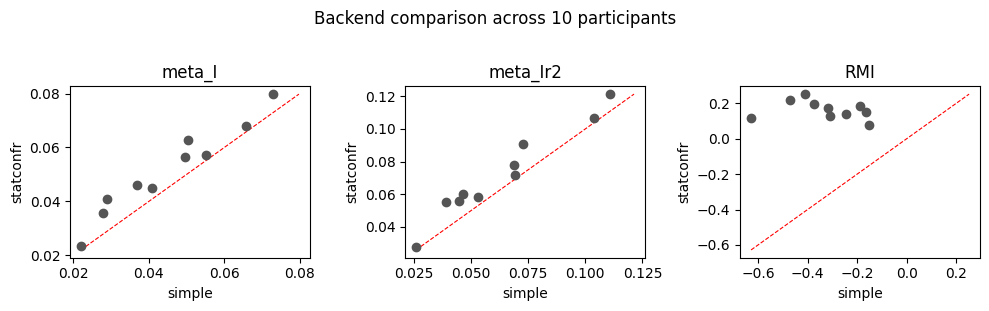

  meta_I: r = 0.9708
  meta_Ir1: r = 0.9551
  meta_Ir2: r = 0.9780


In [11]:
both = pd.merge(
    estimate_meta_I(df_group, backend="simple").add_suffix("_simple")
        .rename(columns={"participant_simple": "participant"}),
    estimate_meta_I(df_group, backend="statconfr").add_suffix("_sc")
        .rename(columns={"participant_sc": "participant"}),
    on="participant",
)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, m in zip(axes, ["meta_I", "meta_Ir2", "RMI"]):
    x, y = both[f"{m}_simple"], both[f"{m}_sc"]
    ax.scatter(x, y, color="#555", zorder=3)
    mn, mx = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([mn, mx], [mn, mx], "r--", lw=0.8)
    ax.set_xlabel("simple")
    ax.set_ylabel("statconfr")
    ax.set_title(m)
plt.suptitle("Backend comparison across 10 participants", y=1.02)
plt.tight_layout()
plt.show()

for m in ["meta_I", "meta_Ir1", "meta_Ir2"]:
    r = both[f"{m}_simple"].corr(both[f"{m}_sc"])
    print(f"  {m}: r = {r:.4f}")

## 9. IT measures vs. traditional meta-d′ measures

IT measures are model-free — they don't assume a Gaussian SDT model.
`meta_I` correlates with M-ratio across participants but captures
different variance.

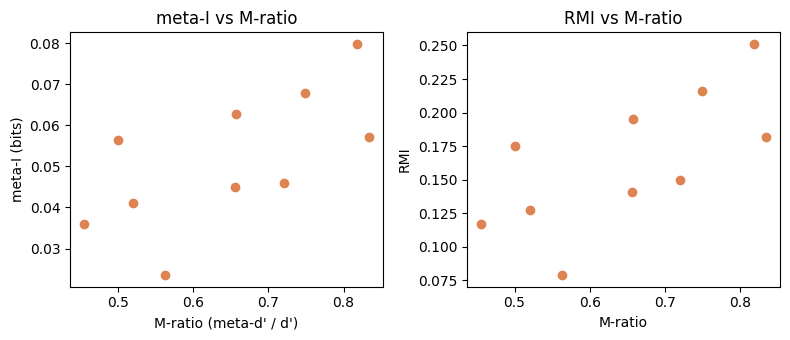

Pearson r(M-ratio, meta-I) = 0.663
Pearson r(M-ratio, RMI)    = 0.683


In [12]:
df_group_std = df_group.rename(
    columns={"stimulus": "Stimuli", "response": "Responses", "rating": "Confidence"})

trad = stdpy.fit_group(df_group_std, subject="participant", nRatings=4,
                        measures=["dprime", "meta_d", "M_ratio"])
it = estimate_meta_I(df_group, backend="statconfr")
merged = pd.merge(trad, it, on="participant")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].scatter(merged["M_ratio"], merged["meta_I"], color=COLORS["statconfr"])
axes[0].set_xlabel("M-ratio (meta-d' / d')")
axes[0].set_ylabel("meta-I (bits)")
axes[0].set_title("meta-I vs M-ratio")

axes[1].scatter(merged["M_ratio"], merged["RMI"], color=COLORS["statconfr"])
axes[1].set_xlabel("M-ratio")
axes[1].set_ylabel("RMI")
axes[1].set_title("RMI vs M-ratio")

plt.tight_layout()
plt.show()

print(f"Pearson r(M-ratio, meta-I) = {merged['M_ratio'].corr(merged['meta_I']):.3f}")
print(f"Pearson r(M-ratio, RMI)    = {merged['M_ratio'].corr(merged['RMI']):.3f}")

## Summary

| Task | Function |
| --- | --- |
| Single measure, one participant | `meta_I(stim, resp, conf, backend=)` |
| All five measures, one participant | `estimate_meta_I(df, backend=, bias_correction=)` |
| All five measures, factorial design | `fit_group(df, subject=, within=, between=, backend=)` |

**Backend choice** — `'simple'` for exploration/speed; `'statconfr'` to
reproduce statConfR results or whenever RMI is needed; add
`bias_correction=True` for small N / publication.

### References
- Dayan P (2023). Metacognitive Information Theory. *Open Mind*, 7, 392–411. doi:10.1162/opmi_a_00091
- Rausch M et al. (2025). statConfR. *JOSS*. doi:10.21105/joss.06966